In [12]:
# Cell 1: 学習曲線データの読み込み
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
    

In [13]:
with open("/tmp/all_steps_seed42.txt") as f:
    steps = [int(l.strip()) for l in f if l.strip()]

print(f"total steps: {len(steps)}")

n_gpu = 8
chunks = [steps[i::n_gpu] for i in range(n_gpu)]  # インターリーブ分割(前半/後半に偏らないように)
for i, c in enumerate(chunks):
    print(f"GPU{i}: {len(c)} steps, range {min(c)}-{max(c)}")
    with open(f"/tmp/steps_gpu{i}.txt", "w") as f:
        f.write(" ".join(map(str, c)))





FileNotFoundError: [Errno 2] No such file or directory: '/tmp/all_steps_seed42.txt'

In [ ]:
def load_save_steps(path, max_steps, num_points=None, interval=None):
    if path is not None:
        p = Path(path)
        if p.suffix == ".json":
            import json
            steps = json.loads(p.read_text())
        else:
            steps = [int(x) for x in p.read_text().split() if x.strip()]
    elif interval is not None:
        steps = list(range(0, max_steps + 1, interval))
        if steps[-1] != max_steps:
            steps.append(max_steps)
    else:
        steps = sorted(set(int(x) for x in np.linspace(0, max_steps, num_points)))
    steps = sorted(s for s in set(steps) if s <= max_steps)
    print(f"save_steps: {len(steps)} points, interval={interval}, "
          f"range=[{steps[0]}, {steps[-1]}]")
    return steps

(6000, 4)
method
conrad              1500
gaussian            1500
ics                 1500
truncated_normal    1500
Name: step, dtype: int64


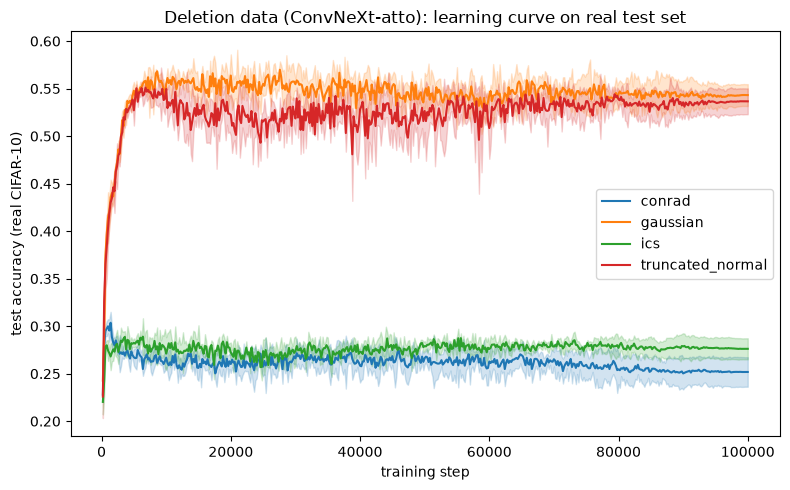

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# 2つのjsonlを結合して読み込み
records = []
for fname in [
    "/home/nakano/server/llc_results_dense/deletion_vision_acc_curve_gpu2.jsonl",
    "/home/nakano/server/llc_results_dense/deletion_vision_acc_curve_gpu3.jsonl",
]:
    with open(fname) as f:
        for line in f:
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(df.shape)
print(df.groupby("method")["step"].count())  # 各手法で何点取れたか確認

# method, step ごとにシード平均・標準偏差
summary = df.groupby(["method", "step"])["test_acc"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
methods = ["conrad", "gaussian", "ics", "truncated_normal"]
colors = plt.cm.tab10.colors

for i, method in enumerate(methods):
    sub = summary[summary["method"] == method].sort_values("step")
    ax.plot(sub["step"], sub["mean"], label=method, color=colors[i])
    ax.fill_between(
        sub["step"], sub["mean"] - sub["std"], sub["mean"] + sub["std"],
        color=colors[i], alpha=0.2,
    )

ax.set_xlabel("training step")
ax.set_ylabel("test accuracy (real CIFAR-10)")
#ax.set_xscale("log")  # DSB論文のFig.4に合わせ対数軸に (低stepでの立ち上がりの違いを見るため)
ax.legend()
ax.set_title("Deletion data (ConvNeXt-atto): learning curve on real test set")
plt.tight_layout()
plt.savefig("/home/nakano/server/llc_results_dense/deletion_vision_learning_curves.png", dpi=150)
plt.show()

/home/nakano/cuda_test/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
usage: ipykernel_launcher.py [-h] [--base-dir BASE_DIR]
                             [--data-root DATA_ROOT]
                             [--methods METHODS [METHODS ...]]
                             [--seeds SEEDS [SEEDS ...]] [--net NET]
                             [--gpu GPU] --out OUT
ipykernel_launcher.py: error: the following arguments are required: --out


SystemExit: 2

/home/nakano/cuda_test/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


ぼつ

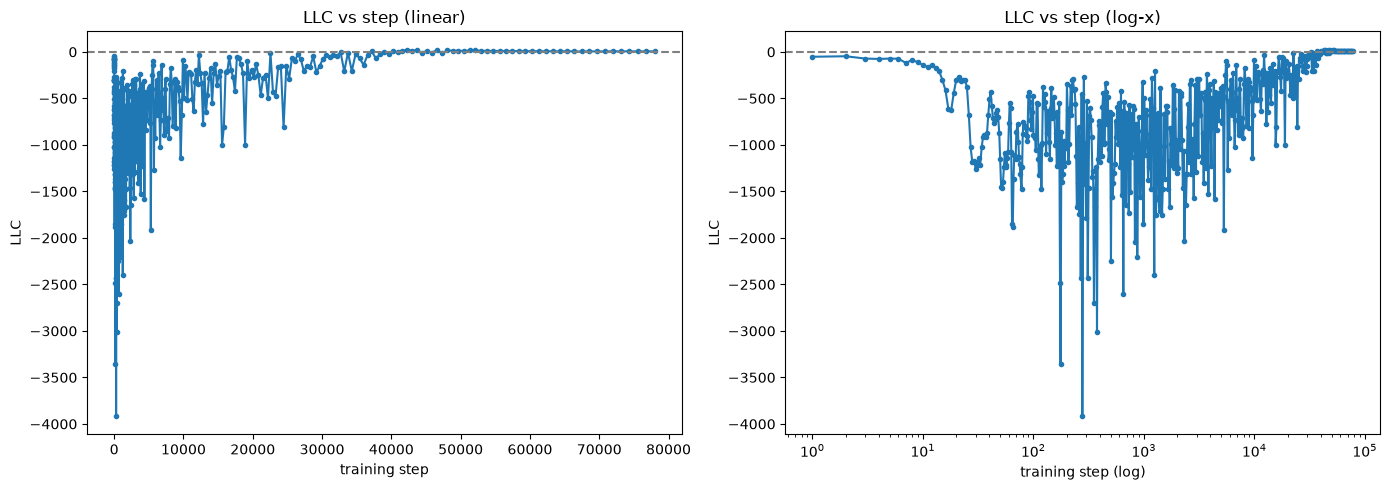

最初に正になるstep: 37167 (それ以前は458点が負)
|llc|>100 の点数: 429
該当step: [    7     9    10    11    12    13    14    15    16    17    18    19
    20    21    22    23    24    25    26    27    28    29    30    31
    32    33    34    35    36    37    38    39    40    41    42    43
    44    45    46    47    48    49    50    51    52    53    54    55
    56    57    58    59    60    61    62    63    64    65    66    67
    68    69    70    72    73    74    75    76    78    79    80    81
    83    84    85    87    88    90    91    93    94    96    97    99
   100   102   104   105   107   109   111   112   114   116   118   120
   122   124   126   128   130   132   134   136   139   141   143   145
   148   150   153   155   158   160   163   165   168   171   174   176
   179   182   185   188   191   194   198   201   204   207   211   214
   218   221   225   228   232   236   240   244   247   252   256   260
   264   268   273   277   282   286   291   295   300   305   3

In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

all_results = []
for gpu in range(8):
    path = Path(f'/home/nakano/server/llc_results_dense/cifar10_train_llc_seed42_chunk{gpu}.json')
    with open(path) as f:
        d = json.load(f)
    all_results.extend(d['results'])

all_results.sort(key=lambda r: r['step'])
steps = np.array([r['step'] for r in all_results])
llcs = np.array([r['mean_llc'] for r in all_results])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(steps, llcs, 'o-', ms=3)
axes[0].axhline(0, ls='--', c='gray')
axes[0].set_xlabel('training step'); axes[0].set_ylabel('LLC')
axes[0].set_title('LLC vs step (linear)')

axes[1].plot(steps, llcs, 'o-', ms=3)
axes[1].axhline(0, ls='--', c='gray')
axes[1].set_xscale('log')
axes[1].set_xlabel('training step (log)'); axes[1].set_ylabel('LLC')
axes[1].set_title('LLC vs step (log-x)')

plt.tight_layout()
plt.show()

# 正になる最初のstepを特定
positive_mask = llcs > 0
first_positive_idx = np.argmax(positive_mask)
print(f"最初に正になるstep: {steps[first_positive_idx]} (それ以前は{first_positive_idx}点が負)")

# 極端な外れ値(|llc|>100)の位置
extreme = np.abs(llcs) > 100
print(f"|llc|>100 の点数: {extreme.sum()}")
print(f"該当step: {steps[extreme]}")

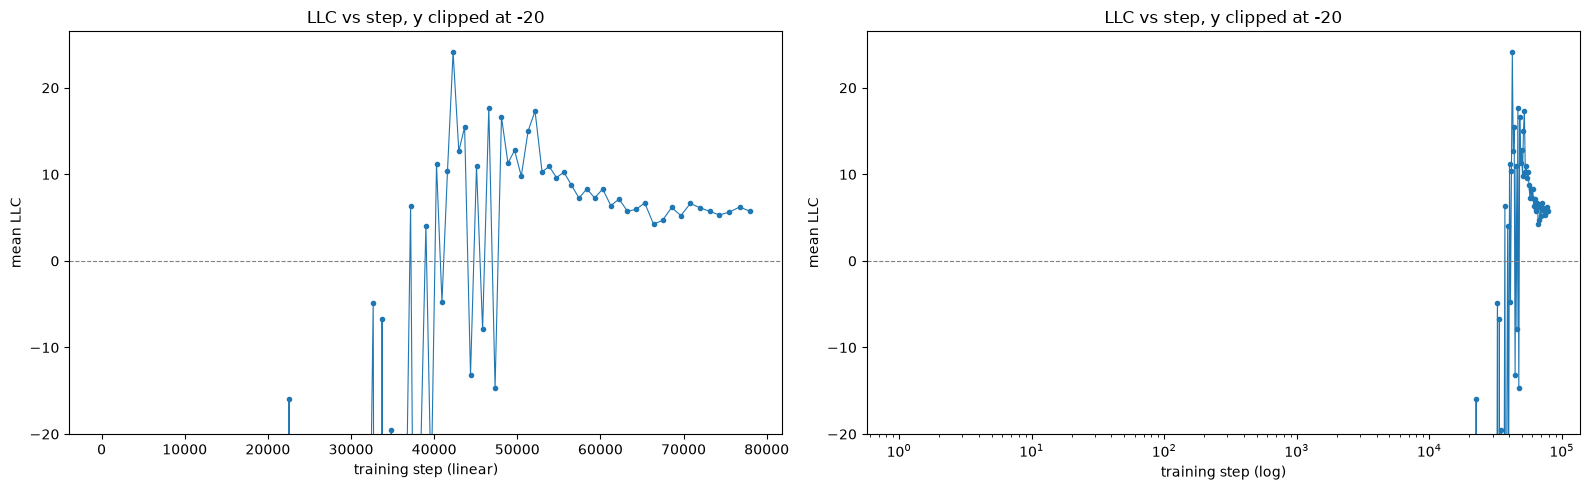

下限-20未満の点数: 457 / 505


In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

all_results = []
for gpu in range(8):
    path = Path(f"/home/nakano/server/llc_results_dense/cifar10_train_llc_seed42_chunk{gpu}.json")
    with open(path) as f:
        d = json.load(f)
    all_results.extend(d["results"])

all_results.sort(key=lambda r: r["step"])
steps = np.array([r["step"] for r in all_results])
llcs = np.array([r["mean_llc"] for r in all_results])

Y_MIN = -20

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, xscale in zip(axes, ["linear", "log"]):
    ax.plot(steps, llcs, "o-", ms=3, lw=0.8, color="C0")
    ax.axhline(0, ls="--", c="gray", lw=0.8)
    ax.set_ylim(Y_MIN, llcs.max() * 1.1)
    ax.set_xscale(xscale)
    ax.set_xlabel(f"training step ({xscale})")
    ax.set_ylabel("mean LLC")
    ax.set_title(f"LLC vs step, y clipped at {Y_MIN}")

plt.tight_layout()
plt.show()

n_clipped = (llcs < Y_MIN).sum()
print(f"下限{Y_MIN}未満の点数: {n_clipped} / {len(llcs)}")

trace length: 15759
accept=0.432, flat_score=0.00381, diverged=True
first NaN/Inf at index=15758
valid trace length: 15758


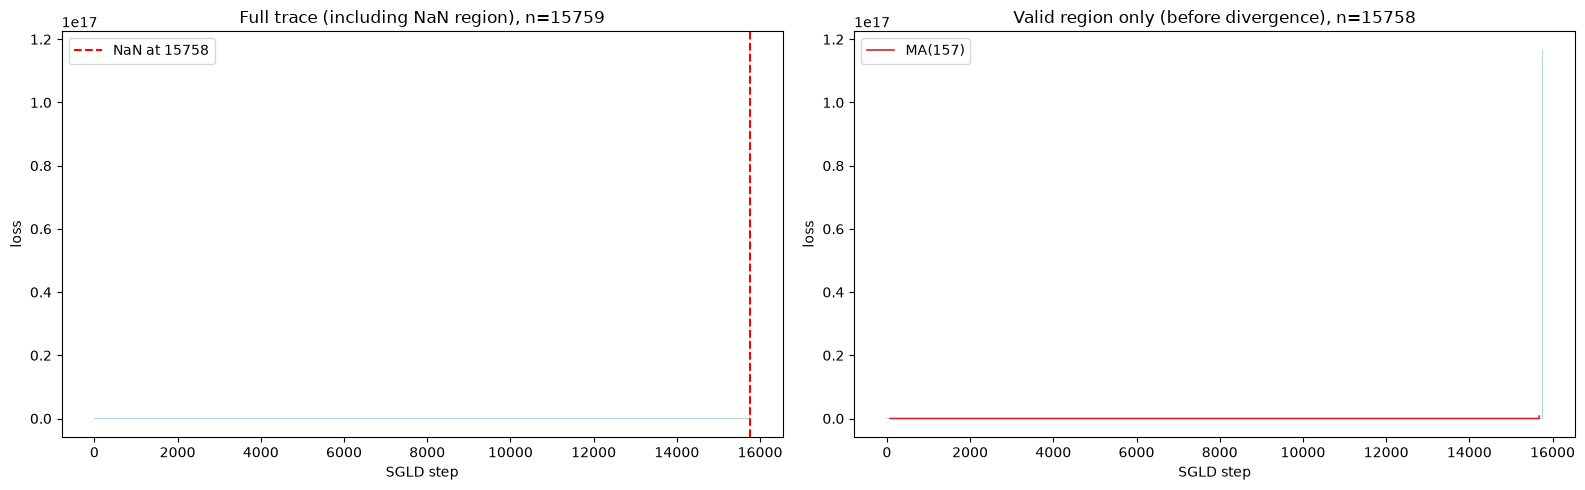

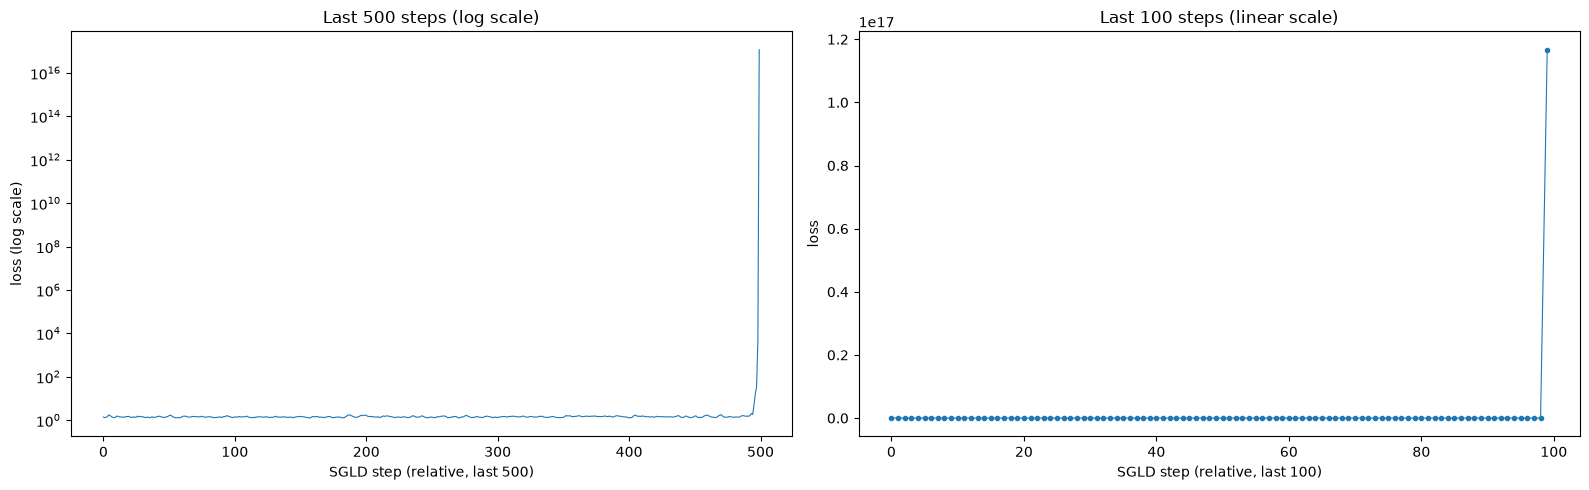

last 50 values before divergence:
  step=15708: 1.550938e+00
  step=15709: 1.562848e+00
  step=15710: 1.359818e+00
  step=15711: 1.341286e+00
  step=15712: 1.346949e+00
  step=15713: 1.320445e+00
  step=15714: 1.428983e+00
  step=15715: 1.530159e+00
  step=15716: 1.653069e+00
  step=15717: 1.701830e+00
  step=15718: 1.694904e+00
  step=15719: 1.545101e+00
  step=15720: 1.428732e+00
  step=15721: 1.405094e+00
  step=15722: 1.360113e+00
  step=15723: 1.351180e+00
  step=15724: 1.320778e+00
  step=15725: 1.408201e+00
  step=15726: 1.575389e+00
  step=15727: 1.676987e+00
  step=15728: 1.801499e+00
  step=15729: 1.566915e+00
  step=15730: 1.405453e+00
  step=15731: 1.379383e+00
  step=15732: 1.376811e+00
  step=15733: 1.373326e+00
  step=15734: 1.475028e+00
  step=15735: 1.438006e+00
  step=15736: 1.403257e+00
  step=15737: 1.379729e+00
  step=15738: 1.357301e+00
  step=15739: 1.406676e+00
  step=15740: 1.396870e+00
  step=15741: 1.390045e+00
  step=15742: 1.384766e+00
  step=15743: 1.52534

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("/home/nakano/server/calibration_results_gamma_eps/verify_fix/calib_seed42_paperlong.json") as f:
    d = json.load(f)

rec = d["records"][0]
tr = np.array(rec["loss_trace"])
n = len(tr)

print(f"trace length: {n}")
print(f"accept={rec['mean_accept_prob']:.3f}, flat_score={rec['flatness_score']:.5f}, diverged={rec['diverged']}")

# Locate NaN/Inf
nan_mask = np.isnan(tr) | np.isinf(tr)
if nan_mask.any():
    first_nan = np.argmax(nan_mask)
    print(f"first NaN/Inf at index={first_nan}")
else:
    first_nan = n
    print("no NaN/Inf found")

valid = tr[:first_nan]
print(f"valid trace length: {len(valid)}")

# --- Figure 1: overview ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(tr, lw=0.4, alpha=0.6, color="C0")
axes[0].axvline(first_nan, ls="--", c="red", label=f"NaN at {first_nan}")
axes[0].set_title(f"Full trace (including NaN region), n={n}")
axes[0].set_xlabel("SGLD step"); axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(valid, lw=0.4, alpha=0.6, color="C0")
w = max(1, len(valid) // 100)
if len(valid) > w:
    ma = np.convolve(valid, np.ones(w)/w, mode="valid")
    axes[1].plot(np.arange(len(ma)) + w//2, ma, lw=1.2, color="C3", label=f"MA({w})")
axes[1].set_title(f"Valid region only (before divergence), n={len(valid)}")
axes[1].set_xlabel("SGLD step"); axes[1].set_ylabel("loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Figure 2: zoom near divergence ---
window = 500
pre_divergence = valid[-window:]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(pre_divergence, lw=0.8, color="C0")
axes[0].set_yscale("log")
axes[0].set_title(f"Last {window} steps (log scale)")
axes[0].set_xlabel(f"SGLD step (relative, last {window})")
axes[0].set_ylabel("loss (log scale)")

window2 = 100
pre_divergence2 = valid[-window2:]
axes[1].plot(pre_divergence2, "o-", ms=3, lw=0.8, color="C0")
axes[1].set_title(f"Last {window2} steps (linear scale)")
axes[1].set_xlabel(f"SGLD step (relative, last {window2})")
axes[1].set_ylabel("loss")

plt.tight_layout()
plt.show()

# Numeric check
print("last 50 values before divergence:")
for i, v in enumerate(valid[-50:]):
    print(f"  step={len(valid)-50+i}: {v:.6e}")

```
python calibrate_gamma_epsilon_dense.py \
    --ckpt_dir /home/nakano/server/checkpoints_dense/dsb_dense/seed42 \
    --seed_label seed42_paperlong \
    --steps 60272 \
    --gammas 1.0 \
    --epsilons 2e-7 \
    --sgld_num_steps 50000 \
    ...
```

first 3000 steps of the eps=2e-7 run
init区間の値: [0.00042801 0.00060287 0.00068663 0.00041844 0.0008104  0.00087857
 0.00075202 0.0007256  0.00102518 0.00089744]
burn-in (step 7200) 以降の平均: 1.171173, std: 0.045641
移動量(概算): 1.170745


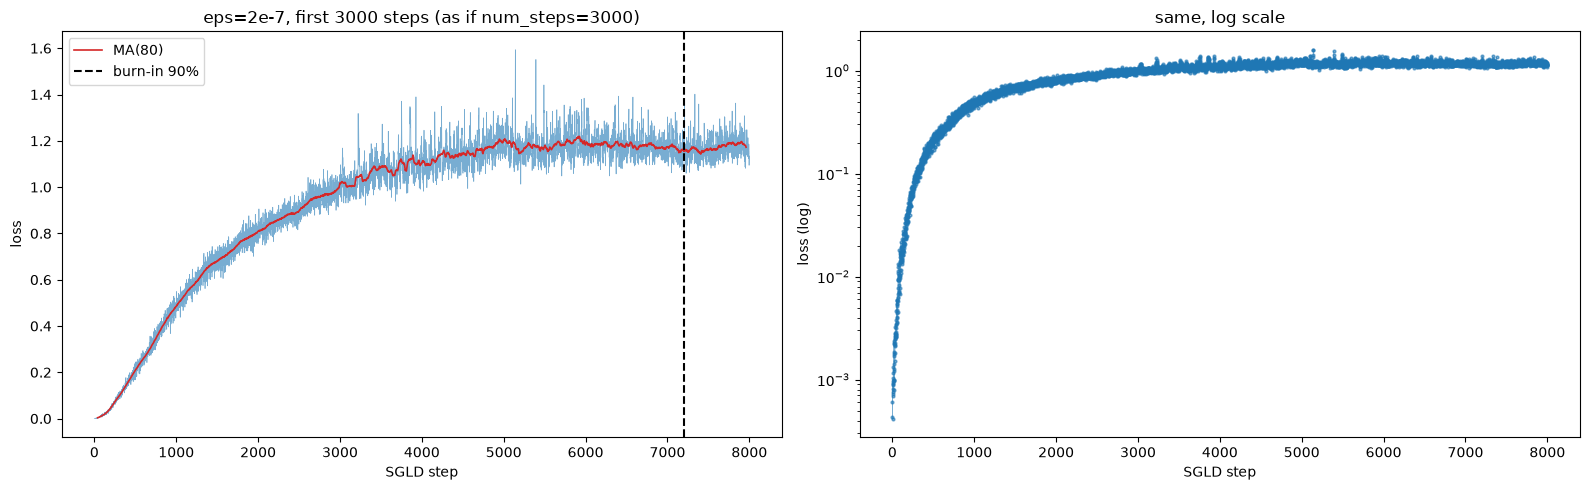

burn-in後4分割平均: ['1.16097', '1.16029', '1.18092', '1.18252']
dict_keys(['seed_label', 'step', 'gamma', 'epsilon', 'init_loss', 'mean_accept_prob', 'in_target_range_0.9_0.95', 'loss_mean_pre_burnin', 'loss_mean_post_burnin', 'flatness_score', 'diverged', 'n_accept_prob_records', 'loss_trace'])


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("/home/nakano/server/calibration_results_gamma_eps/verify_fix/calib_seed42_paperlong.json") as f:
    d = json.load(f)

rec = d["records"][0]
tr_full = np.array(rec["loss_trace"])

# 最初の8000ステップだけを切り出す(本番と同じchain長で何が起きていたか)
tr = tr_full[:8000]
n = len(tr)
b = int(n * 0.9)

print(f"first 3000 steps of the eps=2e-7 run")
print(f"init区間の値: {tr[:10]}")
print(f"burn-in (step {b}) 以降の平均: {tr[b:].mean():.6f}, std: {tr[b:].std():.6f}")

# 参考: 実際のinit_lossを他のrecordから引っ張ってくる必要があるが、
# ここではtrace[0]近辺をinit_lossの代理として使う
init_approx = tr[0]
moved = tr[b:].mean() - init_approx
print(f"移動量(概算): {moved:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(tr, lw=0.5, alpha=0.6, color="C0")
w = max(1, n // 100)
ma = np.convolve(tr, np.ones(w)/w, mode="valid")
axes[0].plot(np.arange(len(ma)) + w//2, ma, lw=1.2, color="C3", label=f"MA({w})")
axes[0].axvline(b, ls="--", c="k", label="burn-in 90%")
axes[0].set_title(f"eps=2e-7, first 3000 steps (as if num_steps=3000)")
axes[0].set_xlabel("SGLD step"); axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(tr, "o-", ms=2, lw=0.3, alpha=0.6, color="C0")
axes[1].set_yscale("log")
axes[1].set_title("same, log scale")
axes[1].set_xlabel("SGLD step"); axes[1].set_ylabel("loss (log)")

plt.tight_layout()
plt.show()

# burn-in後の分割ドリフト確認
quarters = np.array_split(tr[b:], 4)
q_means = [q.mean() for q in quarters]
print(f"burn-in後4分割平均: {[f'{m:.5f}' for m in q_means]}")
# JSON内にaccept probsの生データがあるか確認
print(rec.keys())

In [ ]:
import json
import numpy as np

with open("/home/nakano/server/calibration_results_gamma_eps/verify_fix/calib_seed42_paperlong.json") as f:
    d = json.load(f)

rec = d["records"][0]
tr_full = np.array(rec["loss_trace"])
init_loss = rec["init_loss"]

n_data = 50000
itemp = 1 / np.log(n_data)  # ≈ 0.092423

# 最初の8000ステップを使い、burn-in 90%
tr = tr_full[:8000]
n = len(tr)
b = int(n * 0.9)  # step 7200

valid = tr[b:]
valid = valid[~np.isnan(valid) & ~np.isinf(valid)]

post_burnin_mean = valid.mean()
moved = post_burnin_mean - init_loss
llc = moved * n_data * itemp

print(f"init_loss           = {init_loss:.6f}")
print(f"post_burnin_mean    = {post_burnin_mean:.6f}")
print(f"移動量 (moved)       = {moved:.6f}")
print(f"n_data              = {n_data}")
print(f"itemp (1/log(n))    = {itemp:.6f}")
print(f"n_data * itemp      = {n_data * itemp:.2f}")
print(f"----")
print(f"LLC (8000 steps, burn-in 90%) = {llc:.2f}")

init_loss           = 0.000573
post_burnin_mean    = 1.171173
移動量 (moved)       = 1.170601
n_data              = 50000
itemp (1/log(n))    = 0.092423
n_data * itemp      = 4621.17
----
LLC (8000 steps, burn-in 90%) = 5409.54


In [ ]:
tr3000 = tr_full[:3000]
n3 = len(tr3000)
b3 = int(n3 * 0.9)  # step 2700
valid3 = tr3000[b3:]
valid3 = valid3[~np.isnan(valid3) & ~np.isinf(valid3)]
llc3000 = (valid3.mean() - init_loss) * n_data * itemp
print(f"LLC (3000 steps, burn-in 90%) = {llc3000:.2f}")
print(f"LLC (8000 steps, burn-in 90%) = 5409.54")
print(f"post_burnin_mean (3000) = {valid3.mean():.6f}")

LLC (3000 steps, burn-in 90%) = 4486.51
LLC (8000 steps, burn-in 90%) = 5409.54
post_burnin_mean (3000) = 0.971434


In [ ]:
import json
from pathlib import Path
import numpy as np

RESULT_DIR = Path("/home/nakano/server/llc_results_dense_eps2e7")

all_results = []
for gpu in range(8):
    path = RESULT_DIR / f"cifar10_train_llc_seed42_eps2e7_chunk{gpu}.json"
    if path.exists():
        with open(path) as f:
            d = json.load(f)
        all_results.extend(d["results"])

all_results.sort(key=lambda r: r["step"])
print(f"total: {len(all_results)} / 51 points\n")

print(f"{'step':>8} {'mean_llc':>10} {'chain0_len':>11} {'diverged?':>10}")
for r in all_results:
    c0 = r["chains"][0]
    trace_len = len(c0["loss_trace"])
    diverged = "YES" if trace_len < 10000 else ""
    print(f"{r['step']:>8} {r['mean_llc']:>10.1f} {trace_len:>11} {diverged:>10}")

total: 48 / 51 points

    step   mean_llc  chain0_len  diverged?
      31 439661699.5        9746        YES
      41  1157225.8        9402        YES
      51   684380.6        9663        YES
      61     2165.2       10000           
      72  1079937.4        8611        YES
      84       12.1       10000           
      99      534.6       10000           
     116      -75.0       10000           
     136      736.3       10000           
     160      213.9       10000           
     188       -2.3       10000           
     221      518.4       10000           
     260     -470.4       10000           
     305     1175.6       10000           
     359     -108.4       10000           
     421     1170.9       10000           
     495     1427.8       10000           
     581     1211.6       10000           
     683      822.4       10000           
     803     1846.7       10000           
     943     1195.4       10000           
    1108     1477.4       1000

測った50このtrasceを全て描画する

total results available: 51


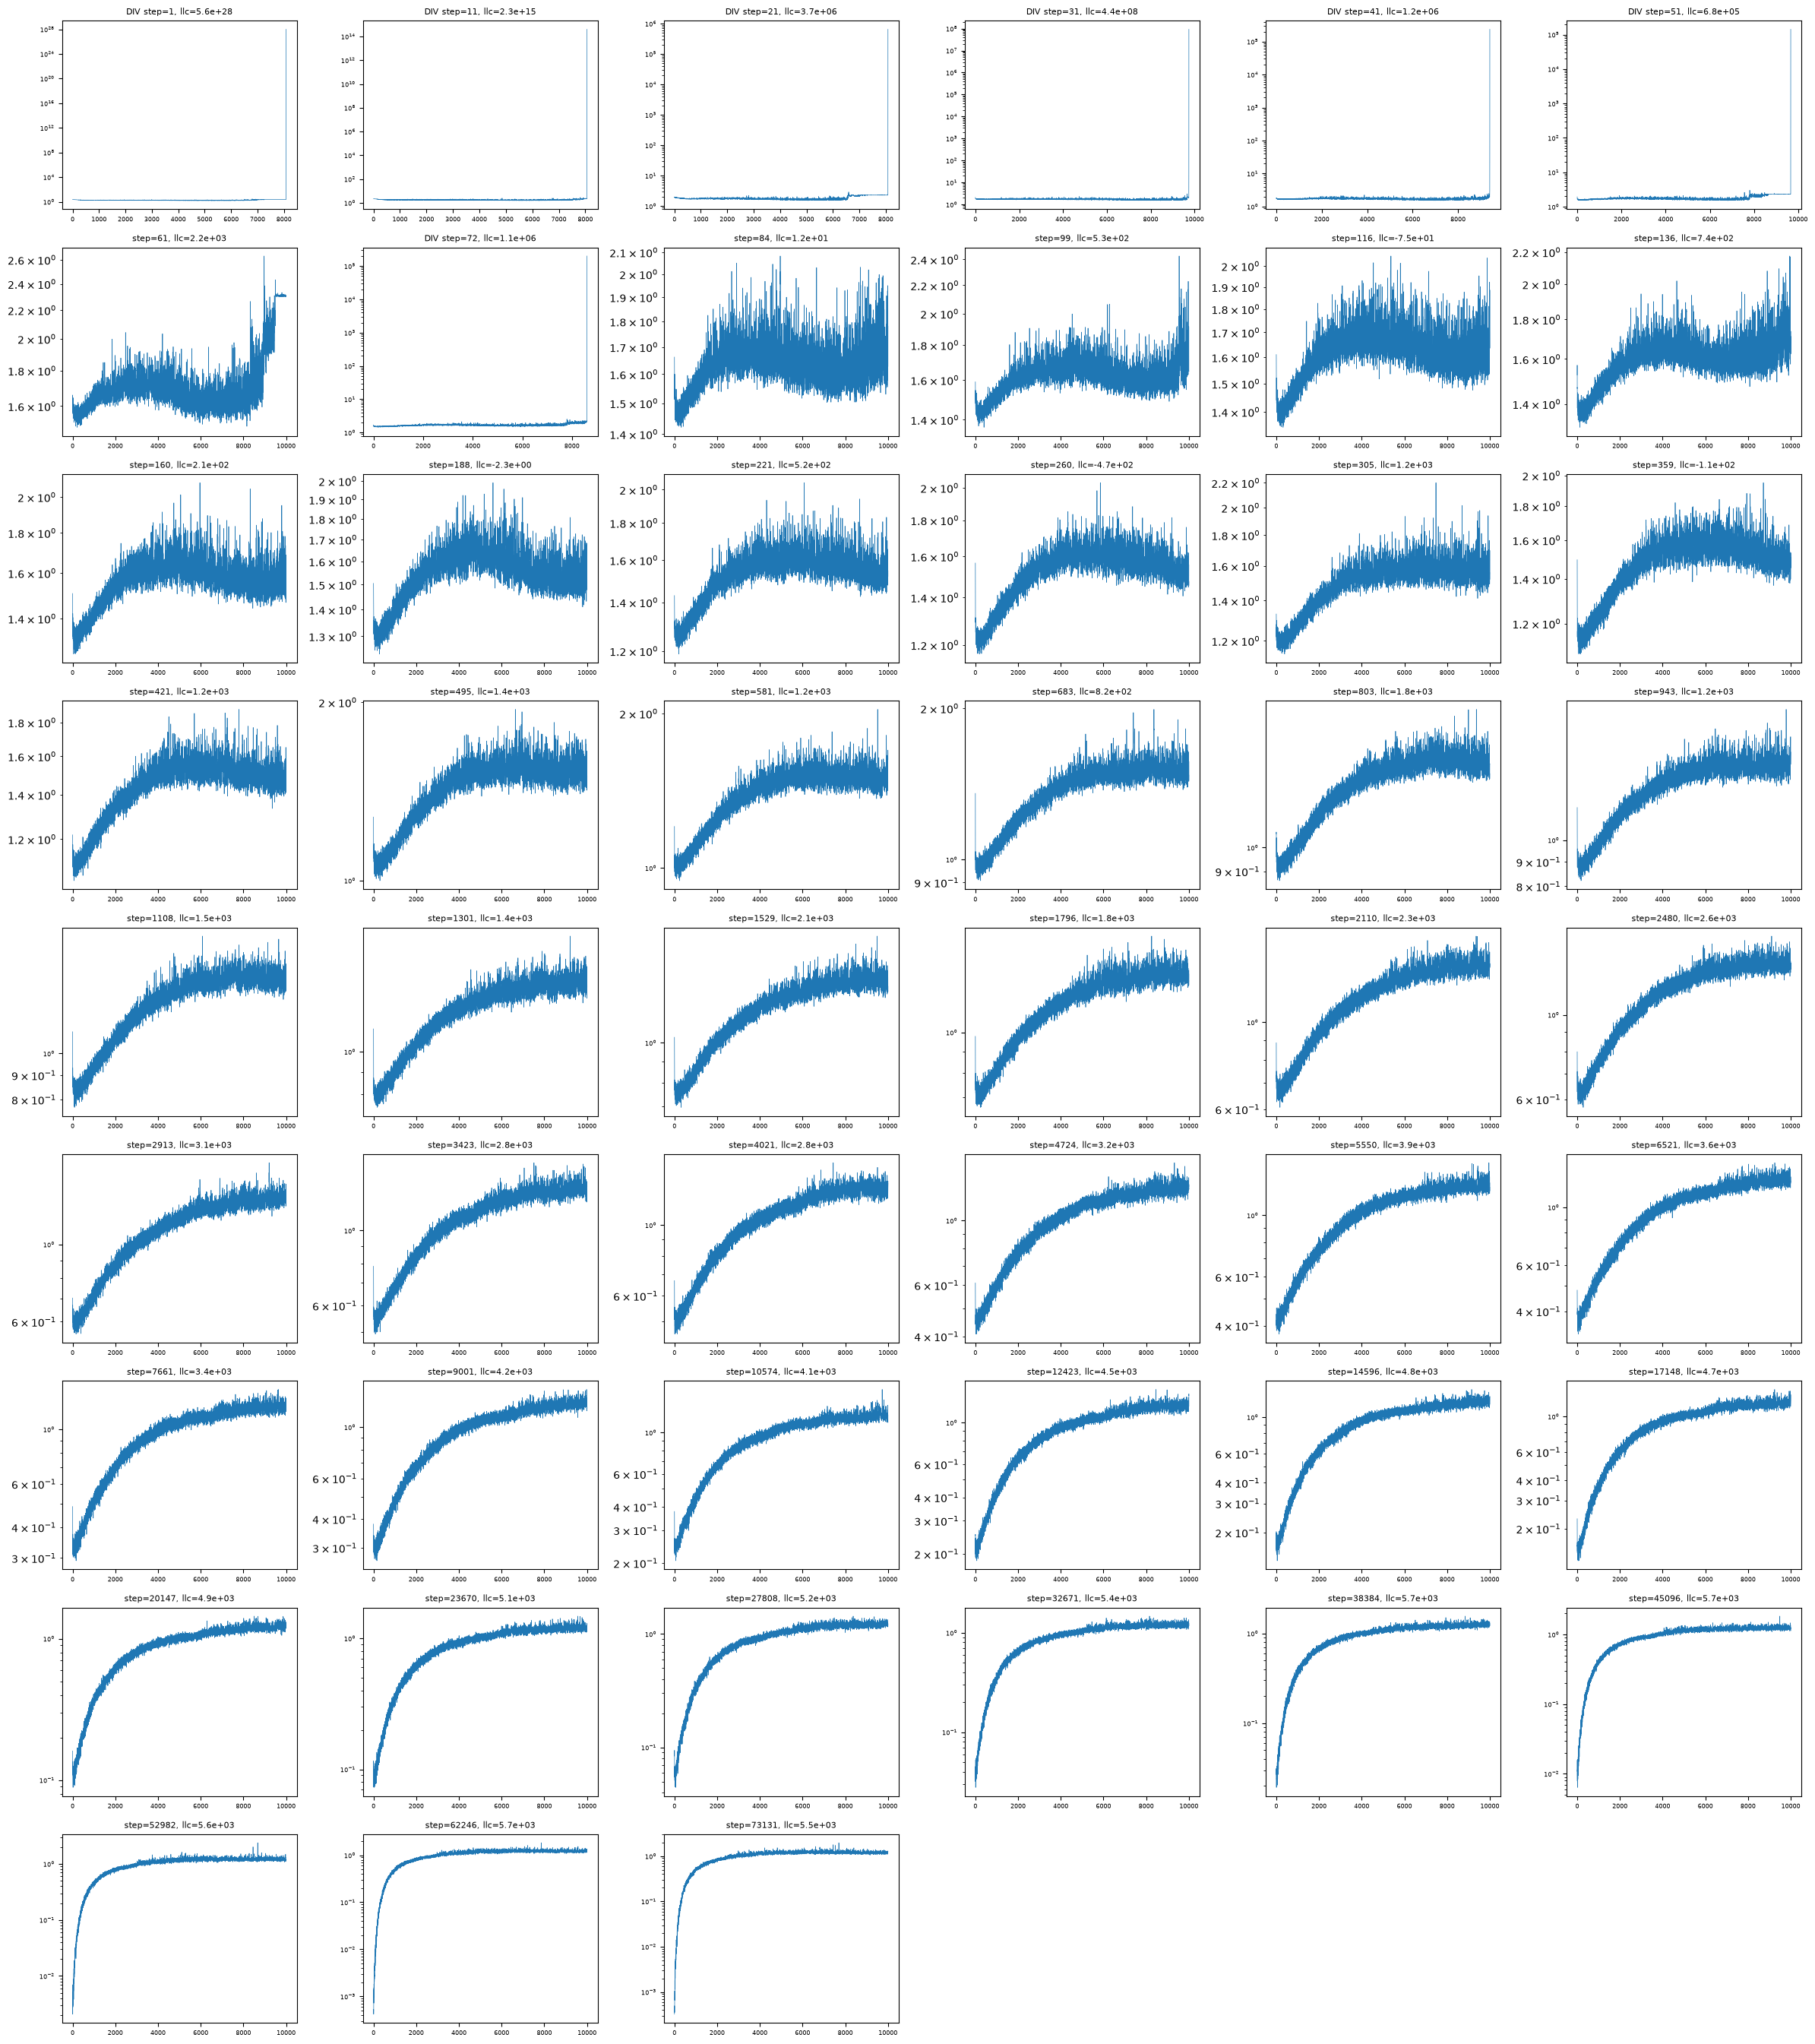

In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULT_DIR = Path("/home/nakano/server/llc_results_dense_eps2e7")

all_results = []
for gpu in range(8):
    path = RESULT_DIR / f"cifar10_train_llc_seed42_eps2e7_chunk{gpu}.json"
    if path.exists():
        with open(path) as f:
            d = json.load(f)
        all_results.extend(d["results"])

all_results.sort(key=lambda r: r["step"])
print(f"total results available: {len(all_results)}")

MAX_PLOT_LEN = 10000  # 何ステップ目まで表示するか(Noneなら全長表示)。
                       # 発散traceも同じ上限で切り詰める(trace自体がそれより短ければそのまま)

n = len(all_results)
ncols = 6
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for ax, rec in zip(axes, all_results):
    tr = np.array(rec["chains"][0]["loss_trace"])
    is_diverged = len(tr) < 10000
    if MAX_PLOT_LEN is not None:
        tr = tr[:MAX_PLOT_LEN]
    ax.plot(tr, lw=0.5, color="C0")
    ax.set_yscale("log")
    diverged = "DIV " if is_diverged else ""
    ax.set_title(f"{diverged}step={rec['step']}, llc={rec['mean_llc']:.1e}", fontsize=8)
    ax.tick_params(labelsize=6)

for ax in axes[len(all_results):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# DSBの結果とLLC

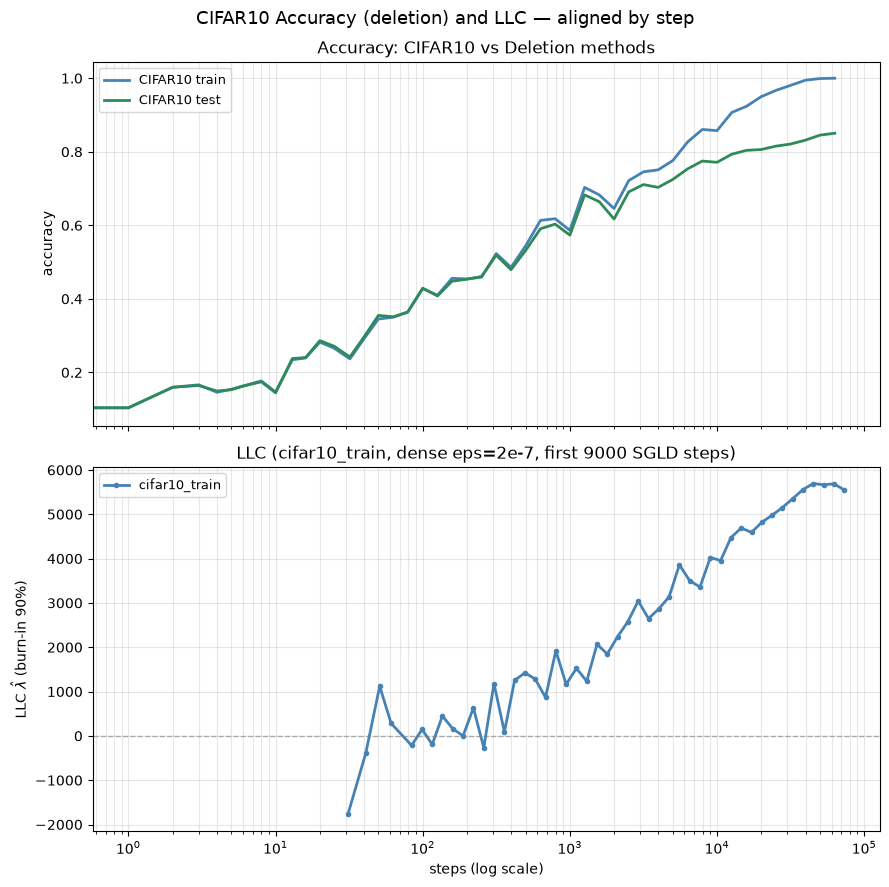

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/home/nakano/cuda_test")
LLC_DENSE_DIR = Path("/home/nakano/server/llc_results_dense_eps2e7")

#DSB_TYPE = "grafting"  # "grafting" or "deletion"
DSB_TYPE = "deletion"  # "grafting" or "deletion"
STEP_LIMIT = None      # LLC(および精度)の表示上限step。Noneなら全範囲
MAX_SGLD_STEPS = 9000  # cifar10_train (dense eps=2e-7) 側のLLC計算に使うSGLDステップ数

n_data = 50000
itemp = 1 / np.log(n_data)

# --- CIFAR10 train/test (共通の基準線) ---
with open(RESULTS_DIR / "dsb_eval_results.json") as f:
    cifar_eval = json.load(f)
cifar_steps     = np.array([r["step"] for r in cifar_eval])
cifar_train_acc = np.array([r["train_acc"] for r in cifar_eval])
cifar_test_acc  = np.array([r["test_acc"] for r in cifar_eval])

# --- DSB手法ごとのファイル名/色 (grafting/deletion切り替え, Accuracyのみに使用) ---
method_names = {
    "grafting": ["bounded_shift", "cqn", "gaussian_ot"],
    "deletion": ["conrad", "gaussian", "ics", "truncated_normal"],
}[DSB_TYPE]

method_colors = {
    "bounded_shift": "darkred", "cqn": "darkorange", "gaussian_ot": "darkviolet",
    "conrad": "darkred", "gaussian": "darkorange", "ics": "darkgreen", "truncated_normal": "darkviolet",
    "cifar10_train": "steelblue",
}

def load_eval_results(name):
    with open(RESULTS_DIR / "eval_results" / f"{name}_full.json") as f:
        return json.load(f)

# --- Accuracy を手法ごとに読み込み ---
acc_curves = {}
for name in method_names:
    eval_path = RESULTS_DIR / "eval_results" / f"{name}_full.json"
    if not eval_path.exists():
        print(f"WARNING: {eval_path} not found, skipping {name} (accuracy)")
        continue
    data = load_eval_results(name)
    acc_curves[name] = (
        np.array([r["step"] for r in data["results"]]),
        np.array([r["accuracy"] for r in data["results"]]),
    )

# --- CIFAR10 (通常データ) のLLC: dense (eps=2e-7) 版, 先頭MAX_SGLD_STEPSステップ・burn-in90%で計算 ---
# (ステップを共有したLLC。手法ごとのLLCはここでは描画しない)
dense_results = []
for gpu in range(8):
    path = LLC_DENSE_DIR / f"cifar10_train_llc_seed42_eps2e7_chunk{gpu}.json"
    if path.exists():
        with open(path) as f:
            d = json.load(f)
        dense_results.extend(d["results"])
dense_results.sort(key=lambda r: r["step"])

cifar_llc_steps, cifar_llc_vals = [], []
for rec in dense_results:
    c0 = rec["chains"][0]
    tr_full = np.array(c0["loss_trace"])
    init_loss = c0["init_loss"]
    if len(tr_full) < MAX_SGLD_STEPS:
        continue
    tr = tr_full[:MAX_SGLD_STEPS]
    b = int(MAX_SGLD_STEPS * 0.9)
    post_mean = tr[b:].mean()
    llc = (post_mean - init_loss) * n_data * itemp
    cifar_llc_steps.append(rec["step"])
    cifar_llc_vals.append(llc)

cifar_llc_steps = np.array(cifar_llc_steps)
cifar_llc_vals = np.array(cifar_llc_vals)

# --- 描画 (上段: Accuracy, 下段: LLC, x軸を共有) ---
fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

# 上段: Accuracy
ax = axes[0]
mask = (cifar_steps <= STEP_LIMIT) if STEP_LIMIT is not None else np.ones_like(cifar_steps, dtype=bool)
ax.plot(cifar_steps[mask], cifar_train_acc[mask], color="steelblue", linewidth=2, label="CIFAR10 train")
ax.plot(cifar_steps[mask], cifar_test_acc[mask],  color="seagreen",  linewidth=2, label="CIFAR10 test")
for name, (steps, accs) in acc_curves.items():
    m = (steps <= STEP_LIMIT) if STEP_LIMIT is not None else np.ones_like(steps, dtype=bool)
    ax.plot(steps[m], accs[m], marker="o", markersize=3, color=method_colors[name], label=name)
ax.set_xscale("log")
ax.set_ylabel("accuracy")
ax.set_title(f"Accuracy: CIFAR10 vs {DSB_TYPE.capitalize()} methods")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# 下段: LLC (cifar10_train, dense eps=2e-7, ステップ共有)
ax = axes[1]
m = (cifar_llc_steps >= 1) & ~np.isnan(cifar_llc_vals)
if STEP_LIMIT is not None:
    m &= (cifar_llc_steps <= STEP_LIMIT)
ax.plot(cifar_llc_steps[m], cifar_llc_vals[m], marker="o", markersize=3,
        color=method_colors["cifar10_train"], linewidth=2, label="cifar10_train")
ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel(r"LLC $\hat{\lambda}$ (burn-in 90%)")
ax.set_title(f"LLC (cifar10_train, dense eps=2e-7, first {MAX_SGLD_STEPS} SGLD steps)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

suffix = f" (steps <= {STEP_LIMIT})" if STEP_LIMIT is not None else ""
fig.suptitle(f"CIFAR10 Accuracy ({DSB_TYPE}) and LLC — aligned by step{suffix}", fontsize=13)
fig.tight_layout()
plt.show()

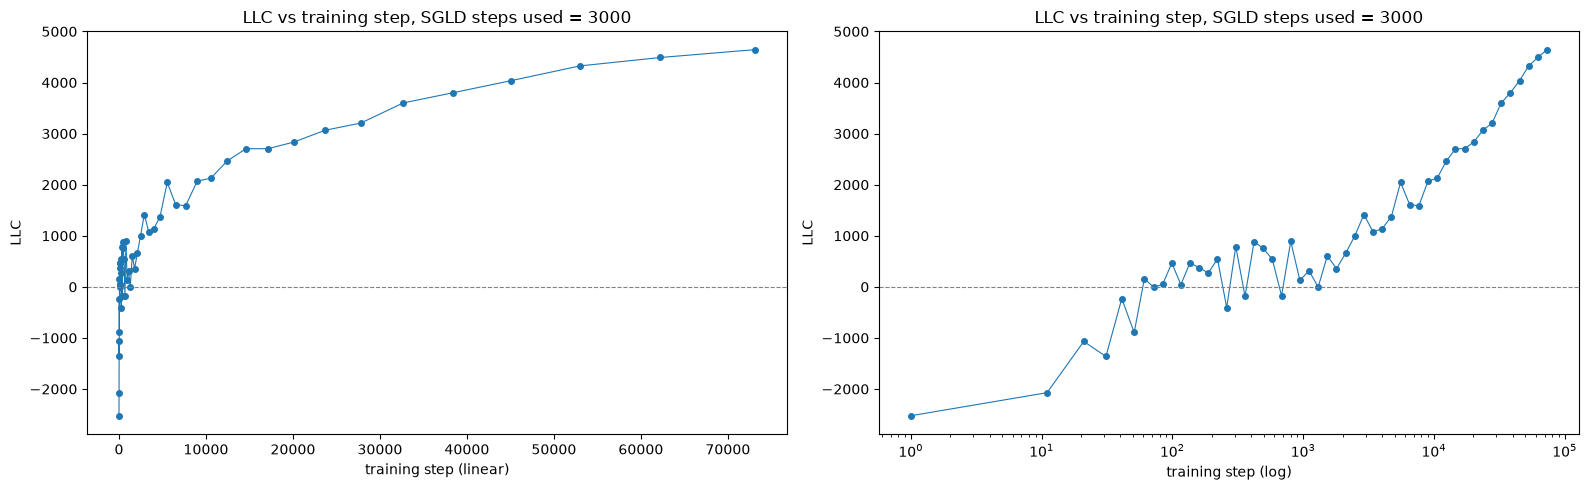


n points included: 51 / 51
 training_step          llc
             1      -2523.3
            11      -2071.4
            21      -1068.4
            31      -1363.5
            41       -230.3
            51       -893.4
            61        158.5
            72         -6.5
            84         46.1
            99        466.9
           116         41.9
           136        467.5
           160        377.2
           188        271.5
           221        545.6
           260       -405.7
           305        789.0
           359       -184.3
           421        886.9
           495        752.8
           581        537.2
           683       -175.7
           803        890.6
           943        127.3
          1108        316.0
          1301         -5.2
          1529        606.8
          1796        356.1
          2110        656.2
          2480        998.8
          2913       1416.3
          3423       1073.5
          4021       1141.3
          4724      

In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULT_DIR = Path("/home/nakano/server/llc_results_dense_eps2e7")

all_results = []
for gpu in range(8):
    path = RESULT_DIR / f"cifar10_train_llc_seed42_eps2e7_chunk{gpu}.json"
    if path.exists():
        with open(path) as f:
            d = json.load(f)
        all_results.extend(d["results"])

all_results.sort(key=lambda r: r["step"])

n_data = 50000
itemp = 1 / np.log(n_data)

# ここを変えて実行し直す
MAX_SGLD_STEPS = 3000

train_steps = []
llc_list = []

for rec in all_results:
    c0 = rec["chains"][0]
    tr_full = np.array(c0["loss_trace"])
    init_loss = c0["init_loss"]
    if len(tr_full) < MAX_SGLD_STEPS:
        print(f"step={rec['step']}: trace too short (len={len(tr_full)} < {MAX_SGLD_STEPS}), skipped")
        continue
    tr = tr_full[:MAX_SGLD_STEPS]
    b = int(MAX_SGLD_STEPS * 0.9)
    post_mean = tr[b:].mean()
    llc = (post_mean - init_loss) * n_data * itemp

    train_steps.append(rec["step"])
    llc_list.append(llc)

train_steps = np.array(train_steps)
llc_arr = np.array(llc_list)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, xscale in zip(axes, ["linear", "log"]):
    ax.plot(train_steps, llc_arr, "o-", ms=4, lw=0.8, color="C0")
    ax.axhline(0, ls="--", c="gray", lw=0.8)
    ax.set_xscale(xscale)
    ax.set_xlabel(f"training step ({xscale})")
    ax.set_ylabel("LLC")
    ax.set_title(f"LLC vs training step, SGLD steps used = {MAX_SGLD_STEPS}")

plt.tight_layout()
plt.show()

print(f"\nn points included: {len(train_steps)} / {len(all_results)}")
print(f"{'training_step':>14} {'llc':>12}")
for s, l in zip(train_steps, llc_arr):
    print(f"{s:>14} {l:>12.1f}")

In [25]:
import json
from pathlib import Path

RESULT_DIR = Path("/home/nakano/server/calibration_results_gamma_eps/accept_recheck_eps2e7")

total_done = 0
for gpu in range(8):
    path = RESULT_DIR / f"calib_seed42_acceptcheck_chunk{gpu}.json"
    if not path.exists():
        print(f"chunk{gpu}: (file not created yet)")
        continue
    with open(path) as f:
        d = json.load(f)
    n = len(d["records"])
    total_done += n
    steps_done = [r["step"] for r in d["records"]]
    print(f"chunk{gpu}: {n} points done -> steps={steps_done}")

print(f"\ntotal: {total_done} / 51 points done")

chunk0: 2 points done -> steps=[73131, 20147]
chunk1: 2 points done -> steps=[62246, 17148]
chunk2: 2 points done -> steps=[52982, 14596]
chunk3: 2 points done -> steps=[45096, 12423]
chunk4: 2 points done -> steps=[38384, 10574]
chunk5: 2 points done -> steps=[32671, 9001]
chunk6: 2 points done -> steps=[27808, 7661]
chunk7: 2 points done -> steps=[23670, 6521]

total: 16 / 51 points done


In [27]:
import json
from pathlib import Path

RESULT_DIR = Path("/home/nakano/server/calibration_results_gamma_eps/accept_recheck_eps2e7")

path = RESULT_DIR / "calib_seed42_acceptcheck_chunk0.json"
with open(path) as f:
    d = json.load(f)

rec = d["records"][0]
print(rec.keys())

dict_keys(['seed_label', 'step', 'gamma', 'epsilon', 'init_loss', 'mean_accept_prob', 'in_target_range_0.9_0.95', 'loss_mean_pre_burnin', 'loss_mean_post_burnin', 'flatness_score', 'diverged', 'n_accept_prob_records', 'loss_trace'])


    step   accept   flat_score   diverged  trace_len
    6521    0.565      0.00001      False      10000
    7661    0.553      0.00001      False      10000
    9001    0.571      0.00002      False      10000
   10574    0.602      0.00003      False      10000
   12423    0.568      0.00001      False      10000
   14596    0.612      0.00003      False      10000
   17148    0.604      0.00003      False      10000
   20147    0.561      0.00001      False      10000
   23670    0.611      0.00000      False      10000
   27808    0.564     -0.00001      False      10000
   32671    0.578      0.00000      False      10000
   38384    0.553     -0.00001      False      10000
   45096    0.505     -0.00001      False      10000
   52982    0.557      0.00004      False      10000
   62246    0.491      0.00004      False      10000
   73131    0.485      0.00005      False      10000


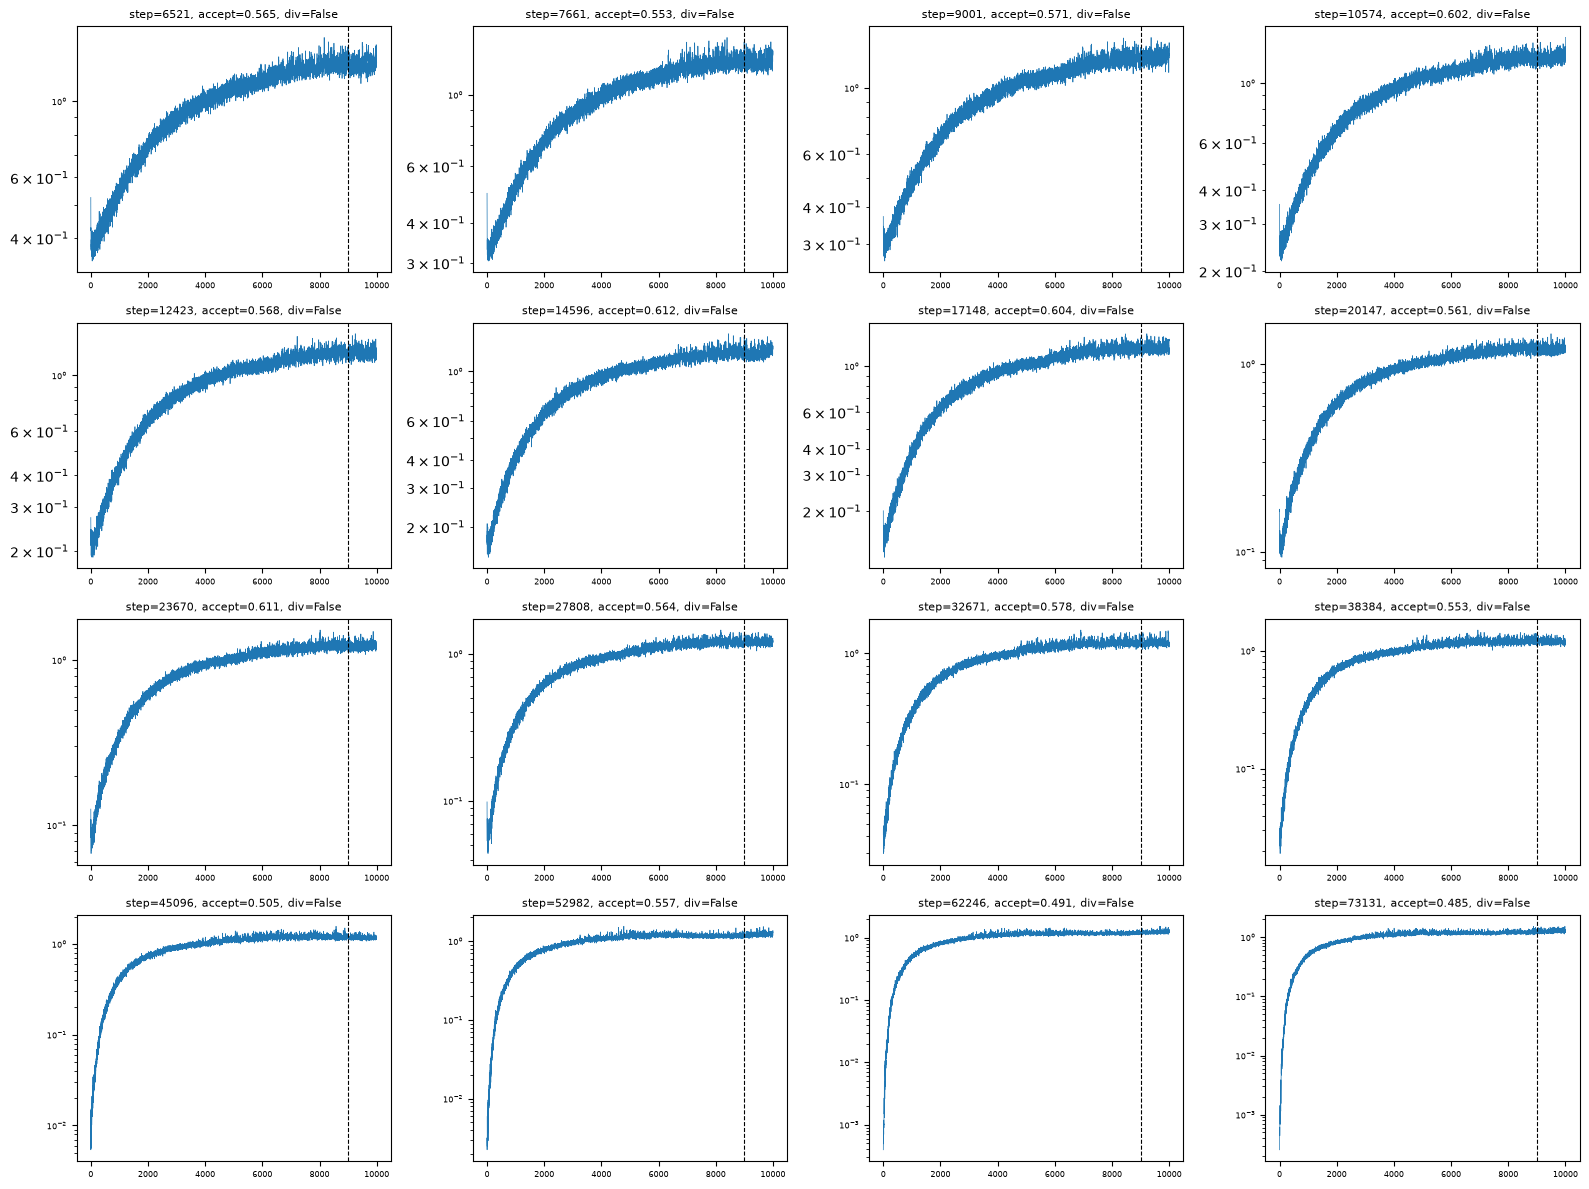

In [29]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULT_DIR = Path("/home/nakano/server/calibration_results_gamma_eps/accept_recheck_eps2e7")

all_done = []
for gpu in range(8):
    path = RESULT_DIR / f"calib_seed42_acceptcheck_chunk{gpu}.json"
    if path.exists():
        with open(path) as f:
            d = json.load(f)
        all_done.extend(d["records"])

all_done.sort(key=lambda r: r["step"])
print(f"{'step':>8} {'accept':>8} {'flat_score':>12} {'diverged':>10} {'trace_len':>10}")
for r in all_done:
    tr_len = len(r["loss_trace"])
    print(f"{r['step']:>8} {r['mean_accept_prob']:>8.3f} {r['flatness_score']:>12.5f} {str(r['diverged']):>10} {tr_len:>10}")

# トレースをグリッド表示
n = len(all_done)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = np.array(axes).flatten()

for ax, rec in zip(axes, all_done):
    tr = np.array(rec["loss_trace"])
    ax.plot(tr, lw=0.5, color="C0")
    ax.set_yscale("log")
    ax.axvline(len(tr)*0.9, ls="--", c="k", lw=0.8)
    ax.set_title(f"step={rec['step']}, accept={rec['mean_accept_prob']:.3f}, div={rec['diverged']}", fontsize=8)
    ax.tick_params(labelsize=6)

for ax in axes[len(all_done):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# キャリブレーション
上記のtraceは2e-7のものであった．traceを見る限り，定常状態になっていてサンプリングがうまくいっているように見えるが，実はMALA採択率が05程度と低かった．
epcilonを変えながら再度計算する必要があるため，
```
EPSILONS = ["2e-8", "5e-8", "1e-7", "2e-7"]
```
で再度計算した．

   eps   accept   flat_score   diverged  trace_len
  2e-8    0.863      0.00012      False      10000
  5e-8    0.779      0.00005      False      10000
  1e-7    0.598      0.00003      False      10000
  2e-7    0.492      0.00005      False      10000


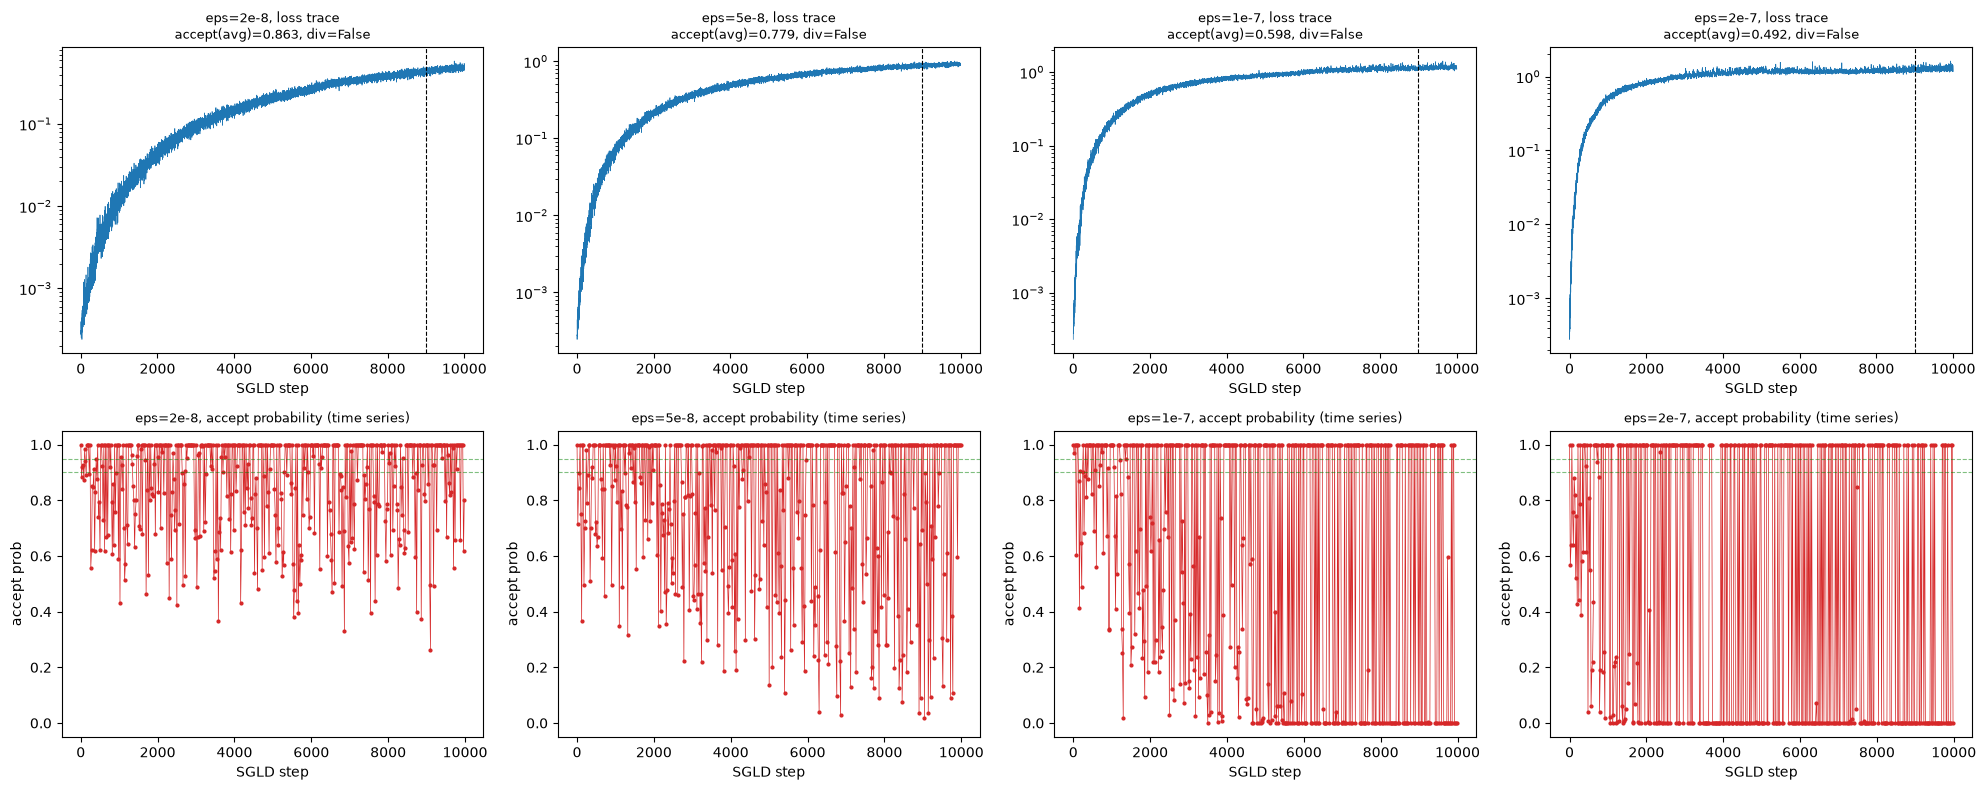

In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULT_DIR = Path("/home/nakano/server/calibration_results_gamma_eps/eps_grid_v2")
EPSILONS = ["2e-8", "5e-8", "1e-7", "2e-7"]

records = {}
for eps in EPSILONS:
    path = RESULT_DIR / f"calib_seed42_epsgrid_{eps}.json"
    with open(path) as f:
        d = json.load(f)
    records[eps] = d["records"][0]

print(f"{'eps':>6} {'accept':>8} {'flat_score':>12} {'diverged':>10} {'trace_len':>10}")
for eps in EPSILONS:
    r = records[eps]
    tr_len = len(r["loss_trace"])
    print(f"{eps:>6} {r['mean_accept_prob']:>8.3f} {r['flatness_score']:>12.5f} {str(r['diverged']):>10} {tr_len:>10}")

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, eps in enumerate(EPSILONS):
    r = records[eps]
    tr = np.array(r["loss_trace"])
    accept_raw = np.array(r["accept_probs_raw"])  # [[t, prob], ...]

    # 上段: lossのtrace
    ax = axes[0, col]
    ax.plot(tr, lw=0.5, color="C0")
    ax.set_yscale("log")
    ax.axvline(len(tr)*0.9, ls="--", c="k", lw=0.8)
    ax.set_title(f"eps={eps}, loss trace\naccept(avg)={r['mean_accept_prob']:.3f}, div={r['diverged']}", fontsize=9)
    ax.set_xlabel("SGLD step")

    # 下段: accept probabilityの時系列
    ax2 = axes[1, col]
    if len(accept_raw) > 0:
        ax2.plot(accept_raw[:, 0], accept_raw[:, 1], "o-", ms=2, lw=0.5, color="C3")
        ax2.axhline(0.9, ls="--", c="green", lw=0.8, alpha=0.5)
        ax2.axhline(0.95, ls="--", c="green", lw=0.8, alpha=0.5)
        ax2.set_ylim(-0.05, 1.05)
    ax2.set_title(f"eps={eps}, accept probability (time series)", fontsize=9)
    ax2.set_xlabel("SGLD step")
    ax2.set_ylabel("accept prob")

plt.tight_layout()
plt.show()

In [3]:
n_data = 50000
itemp = 1 / np.log(n_data)

for eps in EPSILONS:
    r = records[eps]
    tr = np.array(r["loss_trace"])
    b = int(len(tr) * 0.9)
    post_mean = tr[b:].mean()
    llc = (post_mean - r["init_loss"]) * n_data * itemp
    print(f"eps={eps}: init_loss={r['init_loss']:.6f}, post_burnin_mean={post_mean:.6f}, LLC={llc:.1f}")

eps=2e-8: init_loss=0.000301, post_burnin_mean=0.464803, LLC=2146.5
eps=5e-8: init_loss=0.000301, post_burnin_mean=0.901098, LLC=4162.7
eps=1e-7: init_loss=0.000301, post_burnin_mean=1.160298, LLC=5360.5
eps=2e-7: init_loss=0.000301, post_burnin_mean=1.268628, LLC=5861.2
